# Table Distribution Analysis

Reads `data/input.jsonl`, computes numeric **row totals** and **column totals** for each table, and visualises their distributions with boxplots.

In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
JSONL_PATH = Path("D:\TABLE_DATASET\TableBench\TableBench.jsonl")

records = []
with JSONL_PATH.open(encoding="utf-8") as fh:
    for line in fh:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Loaded {len(records)} records")

Loaded 886 records


In [ ]:
def load_jsonl_and_filter(path: str, **filters) -> list[dict]:
    """
    Load a JSONL file and optionally filter records by top-level key-value pairs.

    Parameters
    ----------
    path : str | Path
        Path to the .jsonl file.
    **filters
        Keyword arguments used as equality filters on the top-level keys of each
        record.  E.g. ``qtype="NumericalReasoning"`` keeps only records where
        ``record["qtype"] == "NumericalReasoning"``.

    Returns
    -------
    list[dict]
        Matching records.

    Examples
    --------
    # Load all records
    records = load_jsonl_and_filter("data/input.jsonl")

    # Load only NumericalReasoning / Aggregation entries
    records = load_jsonl_and_filter("data/input.jsonl", qtype="NumericalReasoning", qsubtype="Aggregation")
    """
    records = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if all(rec.get(k) == v for k, v in filters.items()):
                records.append(rec)
    return records


def save_jsonl(records: list[dict], output_path: str) -> None:
    """Write a list of dicts to a JSONL file, one JSON object per line."""
    with open(output_path, "w", encoding="utf-8") as fh:
        for rec in records:
            fh.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f"Saved {len(records)} records → {output_path}")


# ── Load & filter ─────────────────────────────────────────────────────────
JSONL_PATH  = Path(r"D:\TABLE_DATASET\TableBench\TableBench_DP.jsonl")
records = load_jsonl_and_filter(JSONL_PATH, qtype="FactChecking", qsubtype="MatchBased")
print(f"Loaded {len(records)} records (qtype=FactChecking, qsubtype=MatchBased)")

# ── Save filtered subset to JSONL ─────────────────────────────────────────
OUTPUT_PATH = JSONL_PATH.with_stem(JSONL_PATH.stem + "_FactChecking_MatchBased")
save_jsonl(records, OUTPUT_PATH)


Loaded 46 records (qtype=FactChecking, qsubtype=MatchBased)
Saved 46 records → D:\TABLE_DATASET\TableBench\TableBench_DP_DP_FactChecking_MatchBased.jsonl


In [4]:
row_counts = []
col_counts = []

for rec in records:
    table = rec["table"]
    n_rows = len(table["data"])
    n_cols = len(table["columns"])
    row_counts.append(n_rows)
    col_counts.append(n_cols)

sizes = pd.DataFrame({"n_rows": row_counts, "n_cols": col_counts})
print(f"Tables loaded: {len(sizes)}")
print(sizes.to_string(index=True))


Tables loaded: 886
     n_rows  n_cols
0        10       5
1        10       6
2        13       6
3         9       4
4        20      13
5        10      14
6        23       4
7        30       6
8        20       7
9         7      10
10       20       5
11       11       8
12       11       9
13       17       7
14       11       7
15       25       4
16       14       5
17       12       5
18       40       5
19       24       8
20       12       6
21       10       6
22        6       5
23       11       5
24       13       6
25       28       5
26       14       7
27       43       6
28       17       4
29        8       7
30       10       5
31       18       5
32       11       5
33        7       6
34       16       6
35       19       6
36        6       8
37       10       8
38       21       8
39       12      10
40       16       5
41       24       8
42       10       7
43       16       5
44        7      10
45       23       4
46       10       5
47        7       8
4

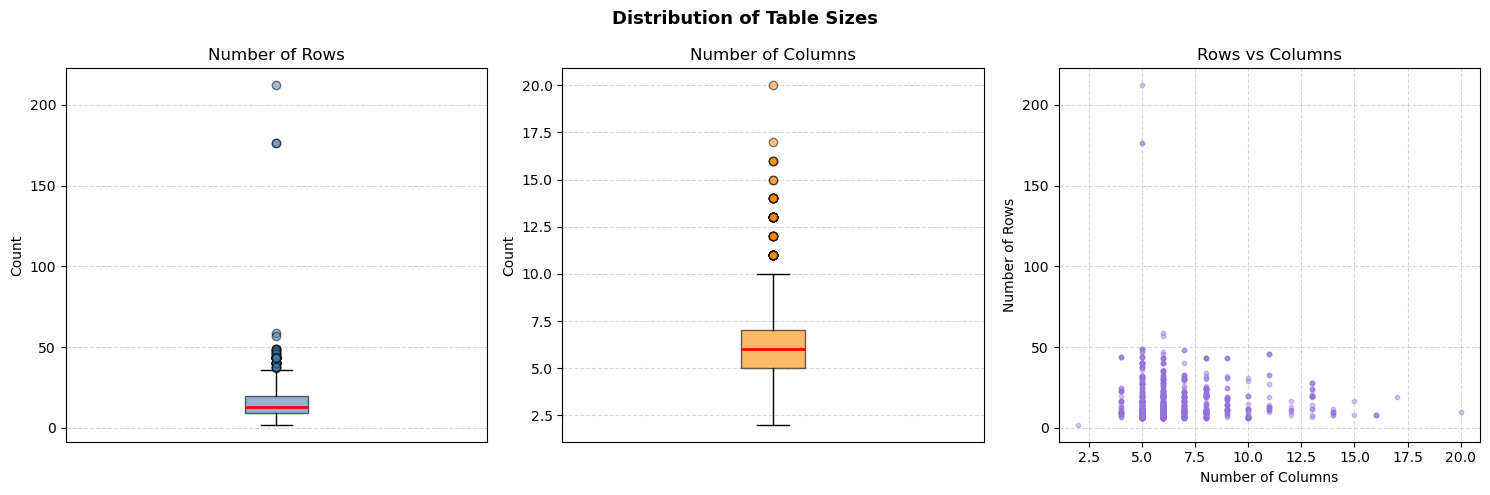

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribution of Table Sizes", fontsize=13, fontweight="bold")

for ax, data, label, color in [
    (ax1, row_counts, "Number of Rows",    "steelblue"),
    (ax2, col_counts, "Number of Columns", "darkorange"),
]:
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor=color, alpha=0.5))
    ax.set_title(label)
    ax.set_ylabel("Count")
    ax.set_xticks([])
    ax.grid(axis="y", linestyle="--", alpha=0.5)

ax3.scatter(col_counts, row_counts, alpha=0.4, s=10, color="mediumpurple")
ax3.set_title("Rows vs Columns")
ax3.set_xlabel("Number of Columns")
ax3.set_ylabel("Number of Rows")
ax3.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [8]:
sizes.describe().round(2)


,n_rows,n_cols
count,886.00,886.00
mean,16.71,6.68
std,14.20,2.13
min,2.00,2.00
25%,9.00,5.00
50%,13.00,6.00
75%,20.00,7.00
max,212.00,20.00


In [3]:
%run src/cli.py 

[table_permutation] Input : D:\TABLE_DATASET\TableBench\FactChecking_MatchBased\TableBench_DP_FactChecking_MatchBased_edited.jsonl
[table_permutation] Output: D:\TABLE_DATASET\TableBench\FactChecking_MatchBased\TableBench_DP_FactChecking_MatchBased_edited_frNone_fc[0].jsonl
[table_permutation] fix_rows=None  fix_cols=[0]  seed=42
[table_permutation] Done – 46 entries written to D:\TABLE_DATASET\TableBench\FactChecking_MatchBased\TableBench_DP_FactChecking_MatchBased_edited_frNone_fc[0].jsonl
[table_permutation] Input : D:\TABLE_DATASET\TableBench\FactChecking_MatchBased\TableBench_DP_FactChecking_MatchBased_edited.jsonl
[table_permutation] Output: D:\TABLE_DATASET\TableBench\FactChecking_MatchBased\TableBench_DP_FactChecking_MatchBased_edited_fr0_fcNone.jsonl
[table_permutation] fix_rows=0  fix_cols=None  seed=42
[table_permutation] Done – 46 entries written to D:\TABLE_DATASET\TableBench\FactChecking_MatchBased\TableBench_DP_FactChecking_MatchBased_edited_fr0_fcNone.jsonl


In [28]:
import sys, importlib
sys.path.insert(0, "src")

# Force-reload so any edits to table_permuter.py take effect
import table_permuter
importlib.reload(table_permuter)
from table_permuter import permute_entry, _TABLE_MARKER

# ── sample entry with an instruction containing a [TABLE] block ───────────
sample = {"id": "29ba53ce7ca43a979263ed36798f62a3", "qtype": "NumericalReasoning", "qsubtype": "Aggregation", "table": {"columns": ["severe tropical cyclones", "tropical cyclones", "season", "strongest storm", "tropical lows"], "data": [["7", "11", "1993 - 94", "theodore", "12"], ["1", "3", "1992 - 93", "oliver", "6"], ["6", "9", "1994 - 95", "chloe", "19"], ["5", "12", "1999 - 00", "john / paul", "13"], ["9", "14", "1995 - 96", "olivia", "19"], ["3", "9", "1997 - 98", "tiffany", "10"], ["7", "10", "1990 - 91", "marian", "10"], ["3", "14", "1996 - 97", "pancho", "15"], ["9", "10", "1991 - 92", "jane - irna", "11"], ["9", "14", "1998 - 99", "gwenda", "21"]]}, "question": "What is the average number of tropical cyclones per season?", "answer": "10.6", "instruction_type": "DP", "instruction": "You are a table analyst. Your task is to answer questions based on the table content.\n\n\nThe answer should follow the format below:\n[Answer Format]\nFinal Answer: AnswerName1, AnswerName2...\n\nEnsure the final answer format is the last output line and can only be in the \"Final Answer: AnswerName1, AnswerName2...\" form, no other form. Ensure the \"AnswerName\" is a number or entity name, as short as possible, without any explanation.\n\n\nGive the final answer to the question directly without any explanation.\n\nRead the table below in JSON format:\n[TABLE] \n{'columns': ['season', 'tropical lows', 'tropical cyclones', 'severe tropical cyclones', 'strongest storm'], 'data': [['1990 - 91', 10, 10, 7, 'marian'], ['1991 - 92', 11, 10, 9, 'jane - irna'], ['1992 - 93', 6, 3, 1, 'oliver'], ['1993 - 94', 12, 11, 7, 'theodore'], ['1994 - 95', 19, 9, 6, 'chloe'], ['1995 - 96', 19, 14, 9, 'olivia'], ['1996 - 97', 15, 14, 3, 'pancho'], ['1997 - 98', 10, 9, 3, 'tiffany'], ['1998 - 99', 21, 14, 9, 'gwenda'], ['1999 - 00', 13, 12, 5, 'john / paul']]}\n\nLet's get start!\nQuestion: What is the average number of tropical cyclones per season?\n"}

# ── permute ────────────────────────────────────────────────────────────────
result = permute_entry(sample, fix_rows=0, fix_cols=0, seed=42)

# ── show results ───────────────────────────────────────────────────────────
print("=== entry[table] BEFORE ===")
print("columns:", sample["table"]["columns"])
print("row 0  :", sample["table"]["data"][0])

print("\n=== entry[table] AFTER ===")
print("columns:", result["table"]["columns"])
print("row 0  :", result["table"]["data"][0])

# Extract [TABLE] block from instruction
def _extract_table_block(instr):
    m = instr.find(_TABLE_MARKER)
    if m == -1:
        return "(marker not found)"
    s = m + len(_TABLE_MARKER)
    e = instr.find("\n", s)
    return instr[s:e if e != -1 else len(instr)]

print("\n=== instruction [TABLE] block BEFORE ===")
print(_extract_table_block(sample["instruction"]))

print("\n=== instruction [TABLE] block AFTER ===")
print(_extract_table_block(result["instruction"]))


=== entry[table] BEFORE ===
columns: ['severe tropical cyclones', 'tropical cyclones', 'season', 'strongest storm', 'tropical lows']
row 0  : ['7', '11', '1993 - 94', 'theodore', '12']

=== entry[table] AFTER ===
columns: ['strongest storm', 'season', 'severe tropical cyclones', 'tropical lows', 'tropical cyclones']
row 0  : ['john / paul', '1999 - 00', '5', '13', '12']

=== instruction [TABLE] block BEFORE ===
{'columns': ['season', 'tropical lows', 'tropical cyclones', 'severe tropical cyclones', 'strongest storm'], 'data': [['1990 - 91', 10, 10, 7, 'marian'], ['1991 - 92', 11, 10, 9, 'jane - irna'], ['1992 - 93', 6, 3, 1, 'oliver'], ['1993 - 94', 12, 11, 7, 'theodore'], ['1994 - 95', 19, 9, 6, 'chloe'], ['1995 - 96', 19, 14, 9, 'olivia'], ['1996 - 97', 15, 14, 3, 'pancho'], ['1997 - 98', 10, 9, 3, 'tiffany'], ['1998 - 99', 21, 14, 9, 'gwenda'], ['1999 - 00', 13, 12, 5, 'john / paul']]}

=== instruction [TABLE] block AFTER ===
{'columns': ['severe tropical cyclones', 'tropical cyclon

## Ollama inference

Run a permuted JSONL file through a locally-running Ollama model.
Results land in `<output_root>/<model_name>/<input_stem>.jsonl`, each line containing `id`, `raw_output`, and `pred_answer`.


In [ ]:
import sys, importlib
sys.path.insert(0, "src")

import ollama_runner
importlib.reload(ollama_runner)
from ollama_runner import run_jsonl

# Run on a permuted file — adjust model name and paths as needed
run_jsonl(
    input_path=r"D:\TABLE_DATASET\TableBench\TableBench_DP_fr0_fc0.jsonl",
    output_root=r"D:\TABLE_DATASET\TableBench\results",
    model="gemma4",          # any model pulled in Ollama
    host="http://134.184.22.126:11434",
    timeout=120,
    workers=1,               # increase for CPU-only or multi-GPU setups
)


[ollama_runner] model   : gemma4
[ollama_runner] input   : D:\TABLE_DATASET\TableBench\TableBench_DP_fr0_fc0.jsonl  (886 entries)
[ollama_runner] output  : D:\TABLE_DATASET\TableBench\results\gemma4\TableBench_DP_fr0_fc0.jsonl
[ollama_runner] host    : http://134.184.22.126:11434  workers=1  timeout=120s
  [1/886] id=29ba53ce7ca43a979263ed36798f62a3  pred='10.6'
  [2/886] id=1aba704991b72a8107475d7fea800b42  pred='1157'
  [3/886] id=39c3b24be6bcb3e279ecccea6b641efc  pred='7391039'
  [4/886] id=e067a40ab6736ac5a004d9dc69f2d5c0  pred='51.44'
  [5/886] id=b71bb2ae2d5e19e17c816355f55ec3d8  pred='41'
  [6/886] id=f19e3c32d88171eb59e66dc31967bf2d  pred='6.16'
  [7/886] id=06cf0ed5987ea6984c584de1d8eda280  pred='108'
  [8/886] id=9a6f45b58f3230e8a11f4f7cd5afa465  pred='468.3'
  [9/886] id=463ca07b585e49a35a8e1e657c4b9cf2  pred='34.93%'
  [10/886] id=1feeafc0b774633c4b7070d7295d0b2a  pred='1.43'
  [11/886] id=d4089b01cb0b1550e4df597512eb8eea  pred='259299'
  [12/886] id=b6ce5ae3244350599a7403a

In [22]:

import json
import re
import sys
from pathlib import Path
import pandas as pd

# ── make the project root importable so 'evaluation' package is found ─────
_proj_root = str(Path().resolve())
if _proj_root not in sys.path:
    sys.path.insert(0, _proj_root)

from evaluation import QAMetric, tablebench_score, parse_prediction

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
Folder_path = r"D:\TABLE_DATASET\TableBench\FactChecking_MatchBased"
model       = "gpt-oss"   #TableGPT2-7B change as needed
prompt_type = "DP"
filename    = "TableBench"

# ---------------------------------------------------------------------------
# 1. Load ground truth  (id → {qtype, qsubtype, question, answer})
# ---------------------------------------------------------------------------
# gt_path = Path(Folder_path) / f"{filename}.jsonl"
gt_path = Path(Folder_path) / f"{filename}_DP_FactChecking_MatchBased_edited.jsonl"
ground_truth = {}
with gt_path.open(encoding="utf-8") as fh:
    for line in fh:
        line = line.strip()
        if not line:
            continue
        entry = json.loads(line)
        ground_truth[entry["id"]] = {
            "qtype":    entry.get("qtype", ""),
            "qsubtype": entry.get("qsubtype", ""),
            "question": entry.get("question", ""),
            "answer":   str(entry.get("answer", "")),
        }

print(f"Ground truth loaded: {len(ground_truth)} entries")

# ---------------------------------------------------------------------------
# 2. Initialise the shared QAMetric engine (loads ROUGE model once)
# ---------------------------------------------------------------------------
metric_engine = QAMetric()
print("QAMetric engine ready.")

# ---------------------------------------------------------------------------
# 3. Parse filename metadata  e.g. TableBench_DP_fr0_fcNone.jsonl
# ---------------------------------------------------------------------------
_META_RE = re.compile(r"_fr(-?\w+)_fc(-?\w+)", re.IGNORECASE)

def parse_file_meta(stem: str) -> dict:
    m = _META_RE.search(stem)
    if m:
        return {"fix_rows": m.group(1), "fix_cols": m.group(2)}
    return {"fix_rows": None, "fix_cols": None}

# ---------------------------------------------------------------------------
# 4. Discover & evaluate all matching result files
# ---------------------------------------------------------------------------
results_dir  = Path(Folder_path) / model
pattern      = f"{filename}_{prompt_type}*.jsonl"
result_files = sorted(results_dir.glob(pattern))

if not result_files:
    print(f"No result files found in {results_dir} matching '{pattern}'")
else:
    print(f"Found {len(result_files)} result file(s):\n  " +
          "\n  ".join(f.name for f in result_files))

rows = []
for result_file in result_files:
    file_meta = parse_file_meta(result_file.stem)

    with result_file.open(encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            res        = json.loads(line)
            entry_id   = res.get("id", "")
            raw_output = res.get("raw_output", "")
            pred       = parse_prediction(raw_output)   # extract from raw_output
            gt         = ground_truth.get(entry_id, {})
            gold       = gt.get("answer", "")
            qtype      = gt.get("qtype", "")
            qsubtype   = gt.get("qsubtype", "")

            score, metric = tablebench_score(
                pred, gold, qtype, qsubtype, engine=metric_engine
            )

            rows.append({
                "id":       entry_id,
                "model":    model,
                "file":     result_file.name,
                "fix_rows": file_meta["fix_rows"],
                "fix_cols": file_meta["fix_cols"],
                "qtype":    qtype,
                "qsubtype": qsubtype,
                "gold":     gold,
                "pred":     pred,
                "metric":   metric,
                "em":       score,   # TableBench-appropriate score (0–1)
            })

eval_df = pd.DataFrame(rows)
# Exclude Visualization: Pass@1 requires code execution and scores 0 for all DP entries
eval_df = eval_df[eval_df["qtype"] != "Visualization"].reset_index(drop=True)
print(f"\nTotal evaluated entries (excl. Visualization): {len(eval_df)}")
print("\nMetric distribution:")
print(eval_df["metric"].value_counts().to_string())

eval_df.head()

Ground truth loaded: 46 entries
QAMetric engine ready.
Found 4 result file(s):
  TableBench_DP_FactChecking_MatchBased_edited.jsonl
  TableBench_DP_FactChecking_MatchBased_edited_fr0_fc1.jsonl
  TableBench_DP_FactChecking_MatchBased_edited_fr0_fcNone.jsonl
  TableBench_DP_FactChecking_MatchBased_edited_frNone_fc1.jsonl

Total evaluated entries (excl. Visualization): 184

Metric distribution:
metric
EM    184


,id,model,file,fix_rows,fix_cols,qtype,qsubtype,gold,pred,metric,em
0,2d94c83349915e453b125fdda0e30f95,gpt-oss,TableBench_DP_FactChecking_MatchBased_edited.j...,None,None,FactChecking,MatchBased,74,74,EM,1.0
1,1c7c310b185c9507faa6e8b0f38a1213,gpt-oss,TableBench_DP_FactChecking_MatchBased_edited.j...,None,None,FactChecking,MatchBased,"UE Lleida, Real Valladolid","UE Lleida, Real Valladolid",EM,1.0
2,c2f777e603e02e71156416f9065b55f5,gpt-oss,TableBench_DP_FactChecking_MatchBased_edited.j...,None,None,FactChecking,MatchBased,Russia,Russia,EM,1.0
3,78f1a1ec29ac20f339fbc3fb396b02d1,gpt-oss,TableBench_DP_FactChecking_MatchBased_edited.j...,None,None,FactChecking,MatchBased,spain,spain,EM,1.0
4,56af57cfe3097874ce49535911e9f039,gpt-oss,TableBench_DP_FactChecking_MatchBased_edited.j...,None,None,FactChecking,MatchBased,germany,germany,EM,1.0


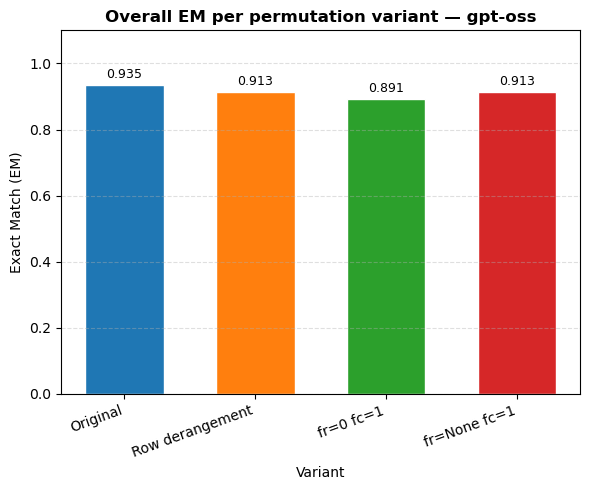

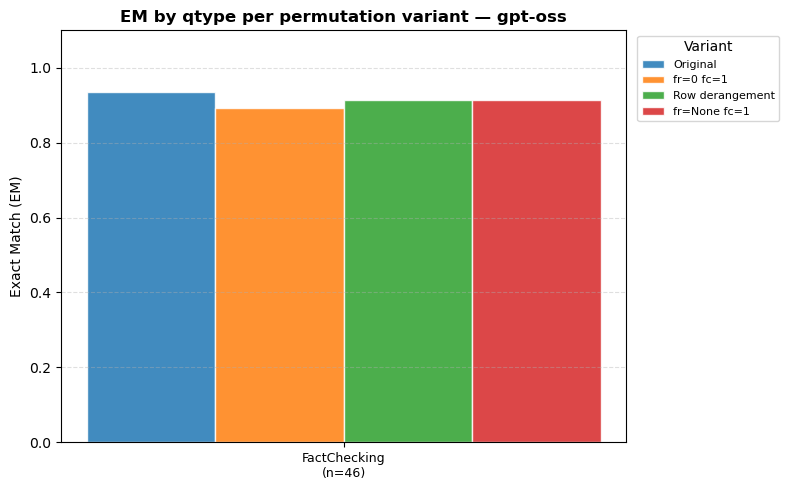

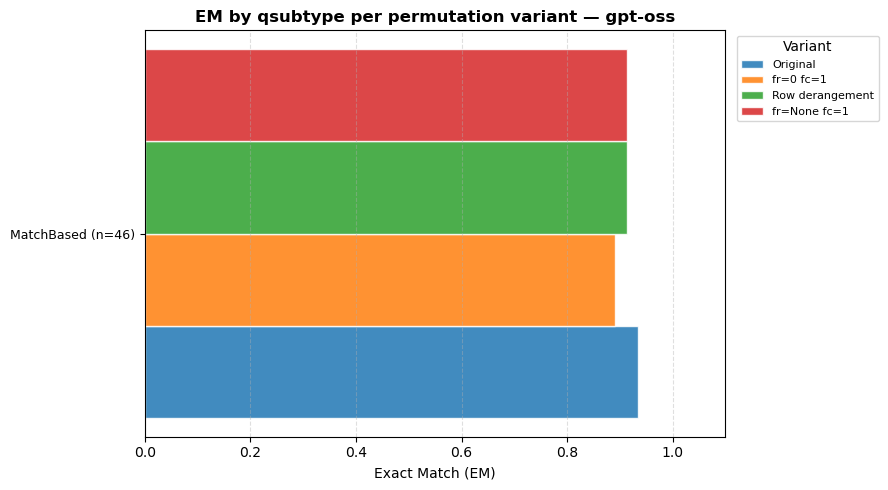

Too few qtypes for radar chart — skipping.


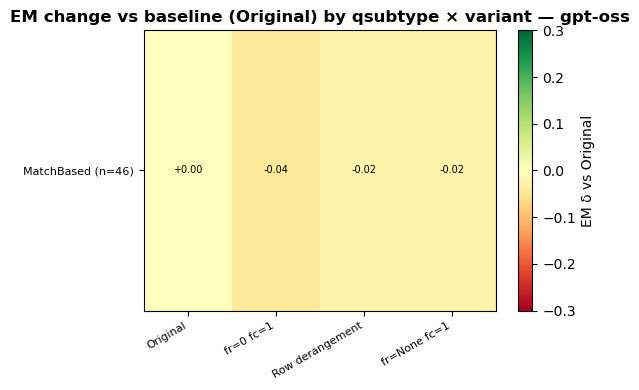

In [23]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── normalise fix_rows/fix_cols: fill NaN (original/baseline file) with "None"
eval_df["fix_rows"] = eval_df["fix_rows"].fillna("None")
eval_df["fix_cols"] = eval_df["fix_cols"].fillna("None")

# ── derived raw variant key ───────────────────────────────────────────────
eval_df["variant"] = "fr=" + eval_df["fix_rows"].astype(str) + " fc=" + eval_df["fix_cols"].astype(str)

# ── human-readable variant names ──────────────────────────────────────────
VARIANT_LABELS = {
    "fr=None fc=None": "Original",
    "fr=0 fc=None":    "Row derangement",
    "fr=None fc=0":    "Col derangement",
    "fr=0 fc=0":       "Row-Col derangement",
}
eval_df["variant"] = eval_df["variant"].map(VARIANT_LABELS).fillna(eval_df["variant"])

variants  = eval_df["variant"].unique().tolist()
qtypes    = sorted(eval_df["qtype"].unique().tolist())
qsubtypes = sorted(eval_df["qsubtype"].unique().tolist())

# ── sample counts per qtype / qsubtype (reference: first available variant) ─
_ref_var      = variants[0]
_ref_slice    = eval_df[eval_df["variant"] == _ref_var]
qt_counts_s   = _ref_slice.groupby("qtype").size()
qsub_counts_s = _ref_slice.groupby("qsubtype").size()

colors = cm.tab10.colors

# =============================================================================
# Plot 1 – Overall EM per variant
# =============================================================================
overall = (
    eval_df.groupby(["file", "variant", "fix_rows", "fix_cols"], dropna=False)["em"]
    .mean()
    .reset_index()
    .sort_values("variant")
)

fig, ax = plt.subplots(figsize=(max(6, len(overall) * 1.2), 5))
bars = ax.bar(overall["variant"], overall["em"],
              color=[colors[i % 10] for i in range(len(overall))],
              edgecolor="white", width=0.6)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Exact Match (EM)")
ax.set_title(f"Overall EM per permutation variant — {model}", fontweight="bold")
ax.set_xlabel("Variant")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 2 – EM by qtype  (grouped bar per variant)
# =============================================================================
qtype_em = (
    eval_df.groupby(["qtype", "variant"], dropna=False)["em"]
    .mean()
    .unstack("variant")
    .reindex(columns=variants)
)

x = np.arange(len(qtype_em))
width = 0.8 / max(len(variants), 1)

fig, ax = plt.subplots(figsize=(max(8, len(qtypes) * 1.8), 5))
for i, var in enumerate(variants):
    if var in qtype_em.columns:
        ax.bar(x + i * width, qtype_em[var], width, label=var,
               color=colors[i % 10], edgecolor="white", alpha=0.85)
ax.set_xticks(x + width * (len(variants) - 1) / 2)
ax.set_xticklabels(
    [f"{qt}\n(n={qt_counts_s.get(qt, 0)})" for qt in qtype_em.index],
    rotation=0, ha="center", fontsize=9
)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Exact Match (EM)")
ax.set_title(f"EM by qtype per permutation variant — {model}", fontweight="bold")
ax.legend(title="Variant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 3 – EM by qsubtype (horizontal bar chart)
# =============================================================================
qsub_em = (
    eval_df.groupby(["qsubtype", "variant"], dropna=False)["em"]
    .mean()
    .unstack("variant")
    .reindex(columns=variants)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, max(5, len(qsub_em) * 0.45)))
y = np.arange(len(qsub_em))
height = 0.8 / max(len(variants), 1)
for i, var in enumerate(variants):
    if var in qsub_em.columns:
        ax.barh(y + i * height, qsub_em[var], height, label=var,
                color=colors[i % 10], edgecolor="white", alpha=0.85)
ax.set_yticks(y + height * (len(variants) - 1) / 2)
ax.set_yticklabels(
    [f"{qs} (n={qsub_counts_s.get(qs, 0)})" for qs in qsub_em.index],
    fontsize=9
)
ax.set_xlim(0, 1.1)
ax.set_xlabel("Exact Match (EM)")
ax.set_title(f"EM by qsubtype per permutation variant — {model}", fontweight="bold")
ax.legend(title="Variant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 4 – Radar chart: permutation invariance across qtypes
# =============================================================================
if len(qtypes) >= 3:
    radar_df = (
        eval_df.groupby(["variant", "qtype"], dropna=False)["em"]
        .mean()
        .unstack("qtype")
        .reindex(columns=qtypes)
        .fillna(0)
    )

    N      = len(qtypes)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    # axis labels include sample count
    radar_labels = [f"{qt}\n(n={qt_counts_s.get(qt, 0)})" for qt in qtypes]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7, color="grey")
    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)

    for i, (var, row) in enumerate(radar_df.iterrows()):
        vals = row.tolist() + row.tolist()[:1]
        ax.plot(angles, vals, "o-", linewidth=2, label=var, color=colors[i % 10])
        ax.fill(angles, vals, alpha=0.08, color=colors[i % 10])

    ax.set_title(f"Permutation invariance radar — {model}\n(EM per qtype per variant)",
                 fontweight="bold", pad=20)
    ax.legend(title="Variant", bbox_to_anchor=(1.25, 1.1), fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Too few qtypes for radar chart — skipping.")

# =============================================================================
# Plot 5 – Heatmap: EM drop relative to baseline (Original if present)
# =============================================================================
baseline = "Original" if "Original" in variants else variants[0]
if len(variants) > 1:
    pivot = (
        eval_df.groupby(["qsubtype", "variant"], dropna=False)["em"]
        .mean()
        .unstack("variant")
        .reindex(columns=variants)
    )
    drop = pivot.subtract(pivot[baseline], axis=0)

    fig, ax = plt.subplots(figsize=(max(6, len(variants) * 1.2),
                                    max(4, len(qsubtypes) * 0.4)))
    im = ax.imshow(drop.values, cmap="RdYlGn", aspect="auto", vmin=-0.3, vmax=0.3)
    fig.colorbar(im, ax=ax, label=f"EM δ vs {baseline}")
    ax.set_xticks(range(len(drop.columns)))
    ax.set_xticklabels(drop.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(drop.index)))
    ax.set_yticklabels(
        [f"{qs} (n={qsub_counts_s.get(qs, 0)})" for qs in drop.index],
        fontsize=8
    )
    for r in range(drop.shape[0]):
        for c in range(drop.shape[1]):
            v = drop.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:+.2f}", ha="center", va="center",
                        fontsize=7, color="black")
    ax.set_title(f"EM change vs baseline ({baseline}) by qsubtype × variant — {model}",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Only one variant – skipping delta heatmap.")


Models found: ['gemma4', 'gpt-oss', 'TableGPT2-7B']
Processing gemma4 / TableBench_DP_FactChecking_MatchBased_edited.jsonl, fix_rows=None, fix_cols=None...
  Evaluating entry 2d94c83349915e453b125fdda0e30f95 — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry 1c7c310b185c9507faa6e8b0f38a1213 — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry c2f777e603e02e71156416f9065b55f5 — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry 78f1a1ec29ac20f339fbc3fb396b02d1 — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry 56af57cfe3097874ce49535911e9f039 — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry 0024501faeb895ca098242a0af2f822a — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry 3e8c9ae6880c285746e8344707583b81 — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry d7b545735f844944b02b05fe0343cb44 — qtype=FactChecking, qsubtype=MatchBased...
  Evaluating entry 6197fb264f5bffbbaadd753cde55c2e5 — qtype=FactChec

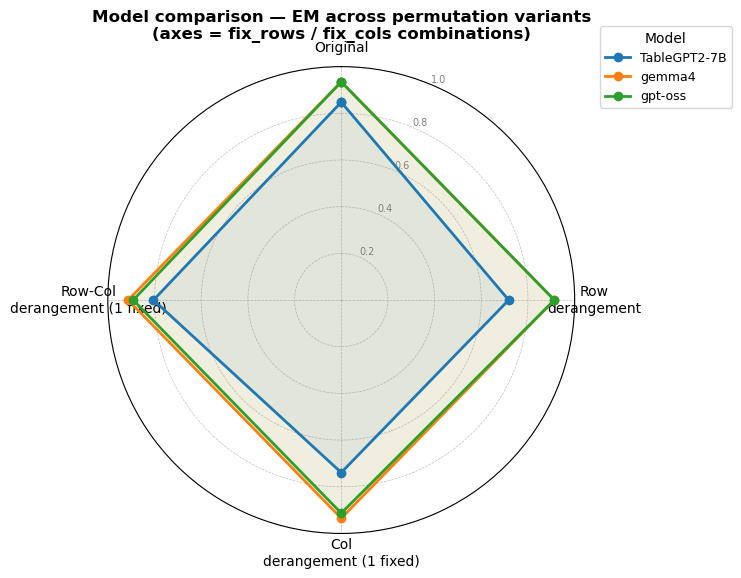

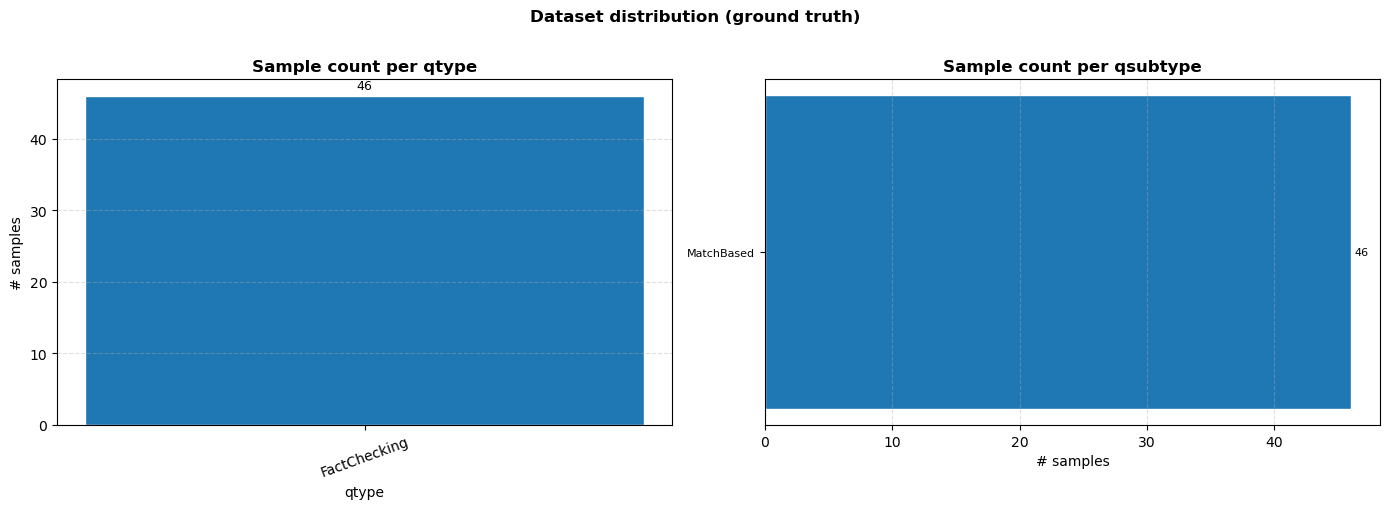

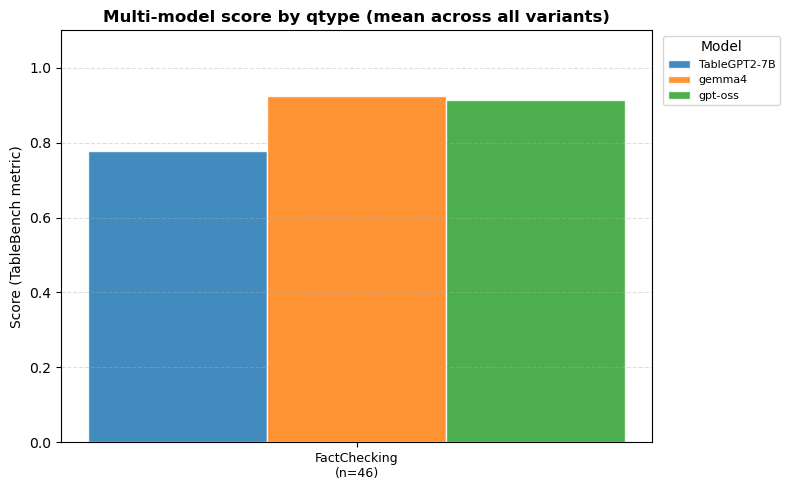

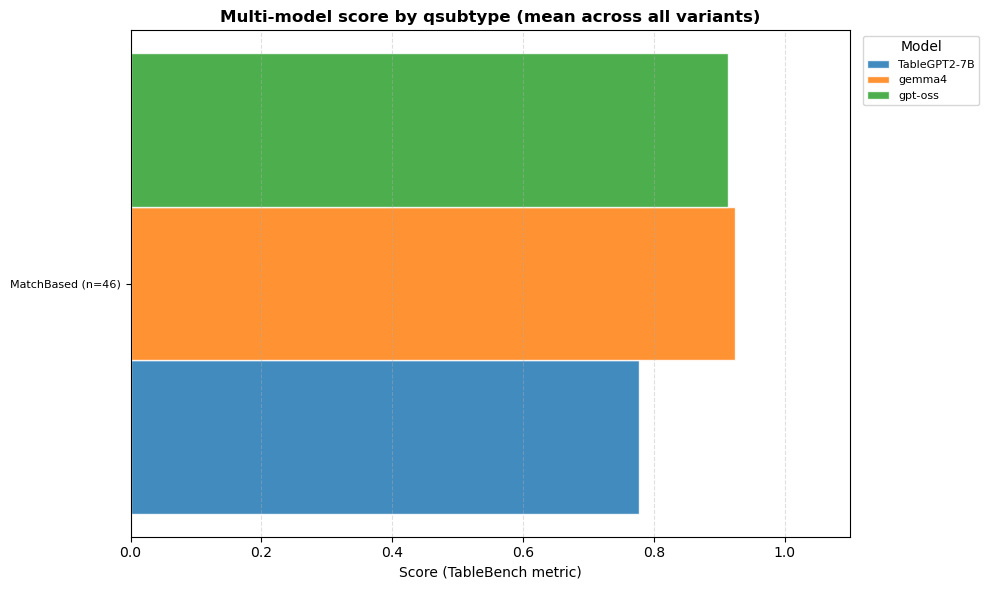

In [28]:

# =============================================================================
# Multi-model analysis: 4 permutation variants × qtype × qsubtype
# =============================================================================
import json, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── imports from the evaluation package ──────────────────────────────────
_proj_root = str(Path().resolve())
if _proj_root not in sys.path:
    sys.path.insert(0, _proj_root)

from evaluation import tablebench_score, parse_prediction
from evaluation.qa_metrics import QAMetric

Folder_path = r"D:\TABLE_DATASET\TableBench\FactChecking_MatchBased"


prompt_type = "DP"
filename    = "TableBench"

# ── shared metric engine (reuse if already instantiated) ──────────────────
if "metric_engine" not in dir():
    metric_engine = QAMetric()

# ── auto-discover all model subdirectories ────────────────────────────────
results_root = Path(Folder_path)
_pattern     = f"{filename}_{prompt_type}_FactChecking_MatchBased_edited*.jsonl"

model_dirs = sorted(
    d for d in results_root.iterdir()
    if d.is_dir() and any(d.glob(_pattern))
)
all_models = [d.name for d in model_dirs]
print(f"Models found: {all_models}")

# ── helpers ────────────────────────────────────────────────────────────────
_META_RE_MULTI = re.compile(r"_fr(-?\w+)_fc(-?\w+)", re.IGNORECASE)

def _parse_meta(stem):
    m = _META_RE_MULTI.search(stem)
    return (m.group(1), m.group(2)) if m else ("None", "None")

# ── build multi-model eval dataframe ──────────────────────────────────────
all_rows = []
for mdir in model_dirs:
    mname = mdir.name
    for rf in sorted(mdir.glob(_pattern)):
        fr, fc = _parse_meta(rf.stem)
        print(f"Processing {mname} / {rf.name}, fix_rows={fr}, fix_cols={fc}...")
        with rf.open(encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                res        = json.loads(line)
                eid        = res.get("id", "")
                raw_output = res.get("raw_output", "")
                pred       = parse_prediction(raw_output)
                gt         = ground_truth.get(eid, {})
                gold       = gt.get("answer", "")
                qtype      = gt.get("qtype", "")

								# removed tab-indented blank line (spaces only)
                print(f"  Evaluating entry {eid} — qtype={qtype}, qsubtype={qsubtype}...")
                score, metric = tablebench_score(
                    pred, gold, qtype, qsubtype, engine=metric_engine
                )

                all_rows.append({
                    "model":    mname,
                    "fix_rows": fr,
                    "fix_cols": fc,
                    "qtype":    qtype,
                    "qsubtype": qsubtype,
                    "metric":   metric,
                    "em":       score,
                })

multi_df = pd.DataFrame(all_rows)
# Exclude Visualization: Pass@1 requires code execution and scores 0 for all DP entries
multi_df = multi_df[multi_df["qtype"] != "Visualization"].reset_index(drop=True)

# ── human-readable variant names ──────────────────────────────────────────
# VARIANT_LABELS = {
#     "fr=None fc=None": "Original",
#     "fr=0 fc=None":    "Row derangement",
#     "fr=None fc=0":    "Col derangement",
#     "fr=0 fc=0":       "Row-Col derangement",
#     "fr=0 fc=1":       "Row-Col derangement (1 fixed)",
#     "fr=None fc=1":       "Col derangement (1 fixed)",
# }

VARIANT_LABELS = {
    "fr=None fc=None": "Original",
    "fr=0 fc=None":    "Row derangement",
    "fr=0 fc=1":       "Row-Col derangement (1 fixed)",
    "fr=None fc=1":       "Col derangement (1 fixed)",
}

multi_df["_raw_variant"] = "fr=" + multi_df["fix_rows"].astype(str) + " fc=" + multi_df["fix_cols"].astype(str)
multi_df["variant"]      = multi_df["_raw_variant"].map(VARIANT_LABELS).fillna(multi_df["_raw_variant"])
print(f"Multi-model entries: {len(multi_df)}")

# AXIS_VARIANTS = ["Original", "Row derangement", "Col derangement", "Row-Col derangement"]
# AXIS_LABELS   = ["Original", "Row\nderangement", "Col\nderangement", "Row-Col\nderangement"]

AXIS_VARIANTS = ["Original", "Row derangement", "Col derangement (1 fixed)", "Row-Col derangement (1 fixed)"]
AXIS_LABELS   = ["Original", "Row\nderangement", "Col\nderangement (1 fixed)", "Row-Col\nderangement (1 fixed)"]


colors        = cm.tab10.colors

# ── sample counts per qtype / qsubtype (one model, baseline variant) ──────
first_model = multi_df["model"].iloc[0]
_ref        = "Original" if "Original" in multi_df["variant"].values else multi_df["variant"].iloc[0]
_ref_slice  = multi_df[(multi_df["model"] == first_model) & (multi_df["variant"] == _ref)]
qt_counts   = _ref_slice.groupby("qtype").size().sort_values(ascending=False)
qsub_counts = _ref_slice.groupby("qsubtype").size().sort_values(ascending=False)

# =============================================================================
# Plot A – Radar: 4 axes = permutation variants, one polygon per model
# =============================================================================
radar_data = (
    multi_df.groupby(["model", "variant"])["em"]
    .mean()
    .reset_index()
    .pivot(index="model", columns="variant", values="em")
    .reindex(columns=AXIS_VARIANTS)
    .fillna(0)
)
radar_data  = radar_data[radar_data.max(axis=1) > 0]
models_plot = radar_data.index.tolist()
print(f"Models in radar: {models_plot}")

N      = len(AXIS_VARIANTS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), AXIS_LABELS, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7, color="grey")
ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
for i, mdl in enumerate(models_plot):
    vals = radar_data.loc[mdl].tolist() + radar_data.loc[mdl].tolist()[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=mdl, color=colors[i % 10])
    ax.fill(angles, vals, alpha=0.07, color=colors[i % 10])
ax.set_title("Model comparison — EM across permutation variants\n(axes = fix_rows / fix_cols combinations)",
             fontweight="bold", pad=20)
ax.legend(title="Model", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot B – Sample count per qtype and qsubtype
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(5, len(qsub_counts) * 0.35 + 1)))

bars1 = ax1.bar(qt_counts.index, qt_counts.values,
                color=[colors[i % 10] for i in range(len(qt_counts))], edgecolor="white")
ax1.bar_label(bars1, padding=3, fontsize=9)
ax1.set_title("Sample count per qtype", fontweight="bold")
ax1.set_ylabel("# samples")
ax1.set_xlabel("qtype")
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

y_pos = np.arange(len(qsub_counts))
ax2.barh(y_pos, qsub_counts.values,
         color=[colors[i % 10] for i in range(len(qsub_counts))], edgecolor="white")
ax2.set_yticks(y_pos)
ax2.set_yticklabels(qsub_counts.index, fontsize=8)
ax2.set_xlabel("# samples")
ax2.set_title("Sample count per qsubtype", fontweight="bold")
ax2.grid(axis="x", linestyle="--", alpha=0.4)
for j, v in enumerate(qsub_counts.values):
    ax2.text(v + 0.3, j, str(v), va="center", fontsize=8)

plt.suptitle("Dataset distribution (ground truth)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot C – Multi-model EM by qtype  (grouped bar, averaged across all variants)
# =============================================================================
qt_model_em = (
    multi_df.groupby(["qtype", "model"])["em"]
    .mean()
    .unstack("model")
    .reindex(columns=models_plot)
    .fillna(0)
)

qtypes_all = qt_model_em.index.tolist()
x = np.arange(len(qtypes_all))
w = 0.8 / max(len(models_plot), 1)

fig, ax = plt.subplots(figsize=(max(8, len(qtypes_all) * 1.8), 5))
for i, mdl in enumerate(models_plot):
    ax.bar(x + i * w, qt_model_em[mdl], w, label=mdl,
           color=colors[i % 10], edgecolor="white", alpha=0.85)
ax.set_xticks(x + w * (len(models_plot) - 1) / 2)
ax.set_xticklabels(
    [f"{qt}\n(n={qt_counts.get(qt, 0)})" for qt in qtypes_all],
    rotation=0, ha="center", fontsize=9
)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score (TableBench metric)")
ax.set_title("Multi-model score by qtype (mean across all variants)", fontweight="bold")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot D – Multi-model EM by qsubtype (horizontal grouped bar)
# =============================================================================
qsub_model_em = (
    multi_df.groupby(["qsubtype", "model"])["em"]
    .mean()
    .unstack("model")
    .reindex(columns=models_plot)
    .fillna(0)
    .sort_index()
)

qsubs_all = qsub_model_em.index.tolist()
y = np.arange(len(qsubs_all))
h = 0.8 / max(len(models_plot), 1)

fig, ax = plt.subplots(figsize=(10, max(6, len(qsubs_all) * 0.5)))
for i, mdl in enumerate(models_plot):
    ax.barh(y + i * h, qsub_model_em[mdl], h, label=mdl,
            color=colors[i % 10], edgecolor="white", alpha=0.85)
ax.set_yticks(y + h * (len(models_plot) - 1) / 2)
ax.set_yticklabels(
    [f"{qs} (n={qsub_counts.get(qs, 0)})" for qs in qsubs_all],
    fontsize=8
)
ax.set_xlim(0, 1.1)
ax.set_xlabel("Score (TableBench metric)")
ax.set_title("Multi-model score by qsubtype (mean across all variants)", fontweight="bold")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

In [ ]:

import json
import base64
import requests
import pymupdf  # pip install pymupdf

OLLAMA_HOST  = "http://134.184.22.126:11434"
OLLAMA_MODEL = "glm-ocr"   # must be a vision-capable model pulled in Ollama
DPI          = 150                 # render resolution per page

# ── Expected output schema (shown to the model as a contract) ─────────────
OUTPUT_SCHEMA = {
    "pages": [
        {
            "page_number": "<int>",
            "regions": [
                {
                    "label":           "<string: type of region, e.g. title/table/figure/paragraph/...>",
                    "recognized_text": "<string: transcribed content of the region>",
                    "bounding_box": {
                        "x":      "<float: left edge, fraction of page width  0–1>",
                        "y":      "<float: top  edge, fraction of page height 0–1>",
                        "width":  "<float: width  as fraction of page width>",
                        "height": "<float: height as fraction of page height>"
                    },
                    "confidence": "<float 0–1: model confidence for this detection>"
                }
            ]
        }
    ]
}


def pdf_pages_to_base64(pdf_path: str, dpi: int = DPI) -> list[str]:
    """Render every PDF page to a PNG and return a list of base64-encoded strings."""
    doc    = pymupdf.open(pdf_path)
    matrix = pymupdf.Matrix(dpi / 72, dpi / 72)
    images = []
    for page in doc:
        pix = page.get_pixmap(matrix=matrix, colorspace=pymupdf.csRGB)
        images.append(base64.b64encode(pix.tobytes("png")).decode("utf-8"))
    doc.close()
    return images


def parse_pdf_with_vision(pdf_path: str) -> dict:
    """
    Render each PDF page as an image, send all pages to a vision model via Ollama,
    and return a structured JSON with detected regions, bounding boxes, labels and
    confidence scores.

    Returns
    -------
    dict  – schema:
        {
          "pages": [
            {
              "page_number": int,
              "regions": [
                {
                  "label":           str,
                  "recognized_text": str,
                  "bounding_box":    {"x": float, "y": float, "width": float, "height": float},
                  "confidence":      float   # 0–1
                }, ...
              ]
            }, ...
          ]
        }
    """
    page_images = pdf_pages_to_base64(pdf_path)
    print(f"Rendered {len(page_images)} page(s) from '{pdf_path}'")

    system_prompt = (
        "You are a document layout analysis assistant. "
        "For each page image you receive, detect every distinct region (title, paragraph, "
        "table, figure, caption, header, footer, list, etc.). "
        "For each region provide:\n"
        "  • label           – region type (e.g. 'title', 'table', 'figure', 'paragraph')\n"
        "  • recognized_text – full transcribed text of the region\n"
        "  • bounding_box    – {x, y, width, height} as fractions of the page dimensions (0.0–1.0), "
        "where (x=0, y=0) is the top-left corner\n"
        "  • confidence      – your confidence score for this detection (0.0–1.0)\n\n"
        "Return ONLY a valid JSON object matching this schema exactly — no explanation, "
        "no markdown fences:\n"
        + json.dumps(OUTPUT_SCHEMA, indent=2)
    )
    user_prompt = (
        f"Analyse all {len(page_images)} page(s) and return the structured JSON."
    )

    payload = {
        "model":  OLLAMA_MODEL,
        "messages": [
            {"role": "system", "content": system_prompt},
            {
                "role":    "user",
                "content": user_prompt,
                "images":  page_images,   # one base64 PNG per page
            },
        ],
        "stream": False,
        "format": "json",
    }

    response = requests.post(
        f"{OLLAMA_HOST}/layout_parsing",
        json=payload,
        timeout=600,
    )
    response.raise_for_status()

    raw_content = response.json()["message"]["content"]
    structured  = json.loads(raw_content)
    return structured


# ── Example usage ─────────────────────────────────────────────────────────
from pathlib import Path

pdf_path = r"C:\Users\wtchuitc\Downloads\TDE Examples.pdf"   # ← change this
result   = parse_pdf_with_vision(pdf_path)

# ── Save JSON output next to the PDF ──────────────────────────────────────
output_path = Path(pdf_path).with_suffix(".json")
with output_path.open("w", encoding="utf-8") as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

print(f"Saved to: {output_path}")
print(json.dumps(result, indent=2, ensure_ascii=False))


Rendered 11 page(s) from 'C:\Users\wtchuitc\Downloads\TDE Examples.pdf'


HTTPError: 404 Client Error: Not Found for url: http://134.184.22.126:11434/layout_parsing

In [9]:
import aiohttp
import asyncio
from pathlib import Path

async def send_pdf_to_ocr(pdf_path: str, ocr_service_url: str = "http://localhost:5002/ocr_metis") -> dict:
	"""
	Send a PDF file to the OCR service deployed locally.
	
	Parameters
	----------
	pdf_path : str
		Path to the PDF file to send
	ocr_service_url : str
		URL of the OCR service endpoint (default: http://localhost:5002/ocr_metis)
	
	Returns
	-------
	dict
		Response from the OCR service containing extracted regions
	"""
	pdf_file = Path(pdf_path)
	
	if not pdf_file.exists():
		raise FileNotFoundError(f"PDF file not found: {pdf_path}")
	
	async with aiohttp.ClientSession() as session:
		with open(pdf_file, 'rb') as f:
			form_data = aiohttp.FormData()
			form_data.add_field('file', f, filename=pdf_file.name, content_type='application/pdf')
			
			try:
				async with session.post(ocr_service_url, data=form_data, timeout=aiohttp.ClientTimeout(total=600)) as resp:
					if resp.status == 200:
						result = await resp.json()
						print(f"OCR processing successful for {pdf_file.name}")
						return result
					else:
						error_text = await resp.text()
						raise Exception(f"OCR service error: {resp.status} - {error_text}")
			except asyncio.TimeoutError:
				raise TimeoutError("OCR service request timed out after 600 seconds")
			except aiohttp.ClientError as e:
				raise Exception(f"Failed to connect to OCR service: {str(e)}")

# Example usage
pdf_path = r"C:\Users\wtchuitc\Downloads\TDE Examples.pdf"

result = await send_pdf_to_ocr(pdf_path)

# Save result to file
output_path = Path(pdf_path).with_stem(Path(pdf_path).stem + "_ocr_result").with_suffix(".json")
with output_path.open("w", encoding="utf-8") as f:
	json.dump(result, f, indent=2, ensure_ascii=False)

print(f"OCR result saved to: {output_path}")
print(json.dumps(result, indent=2, ensure_ascii=False)[:500] + "...")


OCR processing successful for TDE Examples.pdf
OCR result saved to: C:\Users\wtchuitc\Downloads\TDE Examples_ocr_result.json
[
  {
    "content": "R5912698 14 UserGuide.pdf\n",
    "polygon": [
      [
        586,
        186
      ],
      [
        586,
        216
      ],
      [
        146,
        216
      ],
      [
        146,
        186
      ]
    ],
    "type": "paragraph",
    "layout_type": "DefaultBox",
    "nb_tokens": 3,
    "vertical": false,
    "document": "tmprwuxr2w3",
    "page": "",
    "layout_id": "MR1"
  },
  {
    "content": "Asterisks within tables for footnotes\n\nGrouped columns\n",
...
